Today's topics:
* fitting a line with `scipy.stats.linregress`
* interpreting slope, intercept, and predictions
* vectorized predictions and residuals
* MSE, RMSE and MAE: the typical miss, in the units of the property
* $R^2$, and what it does and doesn't tell us
* the residual plot: diagnosing a fit from what it leaves behind

# Where L12 left us

In L12 we measured how strongly yield strength and ultimate tensile strength go together in 190 titanium alloys: $r = 0.882$.
Today we fit a line to those same measurements, use it to predict tensile strength, and see how far off each prediction is.

> The compilation is [Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0.

In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/biomaterials_ti_alloys.csv')

In [2]:
import numpy as np
from scipy import stats

both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])  # 283 rows down to the 190 reporting both
x = both['YS_MPa']
y = both['UTS_MPa']
print(f'{len(both)} alloys, same as L12')

190 alloys, same as L12


# Modeling

Given an alloy's yield strength, what is its ultimate tensile strength likely to be?

So far, we looked at *correlation* which is how strongly these are related.

Next we'll try to produce a **model**.
A model is a simplified representation of a system.
We'll design it to answer a practical question - it is not an exact description!

> "All models are wrong but some are useful." - George Box

> "If you wish to bake an apple pie from scratch, you must first invent the universe." - Carl Sagan

# Fitting a line: `stats.linregress`

$r$ describes how closely the points follow a line, but not the line's slope or intercept.
`stats.linregress` fits `y = m*x + b` by "least squares" and returns an object with named fields ("attributes").

Least squares returns the line with the smallest total squared deviations from the data (it is closely related to the squared deviations we used to build `r` in L12).

In [3]:
fit = stats.linregress(x, y)

print(f'slope     = {fit.slope:.3f}')
print(f'intercept = {fit.intercept:.1f} MPa')
print(f'r         = {fit.rvalue:.3f}')

slope     = 0.985
intercept = 204.3 MPa
r         = 0.882


`fit.rvalue` is the same 0.882 that `stats.pearsonr` returned as `r` in L12.
The fit contains it because the correlation and the line are two different answers to the same question about these columns (how strongly are they correlated?).

## Reading the fitted equation

The fitted line is `UTS = 0.985 * YS + 204`.

Because both axes use MPa, the slope means 0.985 MPa of predicted tensile strength per 1 MPa of yield strength.

The intercept is the model's predicted tensile strength at zero yield strength (not really a physical quantity in this case).

# Prediction

Substituting a yield strength into the fitted equation gives a predicted tensile strength.

In [4]:
pred_800 = fit.slope * 800 + fit.intercept
print(f'800 MPa yield strength predicts {pred_800:.0f} MPa tensile strength')

800 MPa yield strength predicts 992 MPa tensile strength


The alloys this line was fit on run from 130 to 1880 MPa of yield strength, so 800 sits well inside them.
A prediction inside the fitted range is **interpolation**, and the surrounding data is what supports it.

In [5]:
print(f'{np.min(x):.0f} to {np.max(x):.0f} MPa of yield strength in the fitted alloys')

pred_2500 = fit.slope * 2500 + fit.intercept
print(f'2500 MPa yield strength predicts {pred_2500:.0f} MPa tensile strength')

130 to 1880 MPa of yield strength in the fitted alloys
2500 MPa yield strength predicts 2666 MPa tensile strength


2500 MPa is beyond every alloy in the table, which makes that second number **extrapolation**.

Python returned a value because the calculation applies the equation without checking the fitted range.
This compilation does not support extending the same slope that far.

# Vectorized prediction

Above we predicted tensile strength from one yield strength at a time.
Passing every yield strength to the equation at once predicts every tensile strength, with no loop required.

In [6]:
y_hat = fit.slope * x + fit.intercept  # one line, 190 predictions
display(y_hat)

12      546.897436
13      800.917610
14      819.624522
15      823.562820
20      732.981982
          ...     
278    1753.985553
279    1878.041917
280    1651.589824
281    1779.584485
282    2055.265295
Name: YS_MPa, Length: 190, dtype: float64

`y_hat` is 190 predictions, one per alloy, computed in one vectorized line.

## Drawing the fitted line

We have the alloy measurements in `x` and `y`, so let's see what `ax.plot(x, y)` draws before adding the fit.

Text(0, 0.5, 'ultimate tensile strength (MPa)')

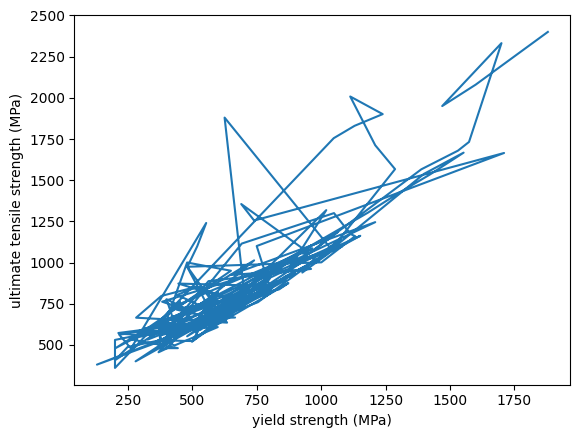

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')

That is a scribble.

`ax.plot` draws a segment from each point to the next one in the order they are stored, and `x` is in whatever order the compilation happened to list the alloys.
So the line runs to a high yield strength, back to a low one, and forward again: across its 189 segments the direction reverses 80 times.

Plotting `y_hat` against `x` the same way would join the 190 predictions in row order.
Every prediction sits on the fitted line, so it would look like a line, but it would still be 189 segments retracing it back and forth.

## Two x values instead of the whole column

A straight line needs exactly two points, so take the smallest and largest yield strength and put those through the equation.
The smallest and largest are guaranteed to be in order, which is the whole of the problem above.

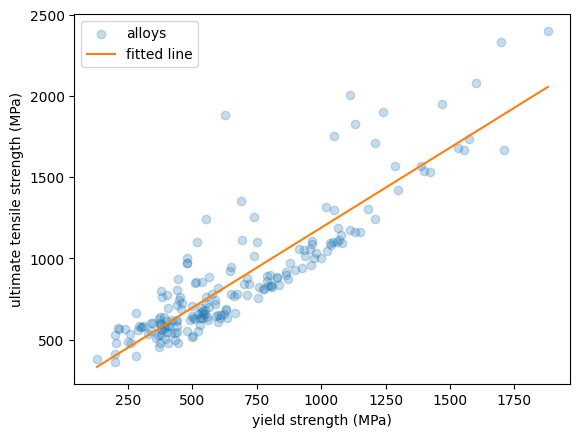

In [8]:
xx = np.array([np.min(x), np.max(x)])
yy = fit.slope * xx + fit.intercept

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label='alloys')
ax.plot(xx, yy, color='tab:orange', label='fitted line')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

## Residuals

The residual is the gap between what actually happened and what the line predicted: `residual = y - y_hat`.

In [9]:
residuals = y - y_hat  # measured minus predicted, so negative means the line was too optimistic
display(residuals)
print(f'sum of residuals: {np.sum(residuals):.6f}')  # zero, up to rounding

12      54.102564
13    -167.917610
14    -163.624522
15    -134.562820
20     119.018018
          ...    
278    -21.985553
279    453.958083
280    298.410176
281    300.415515
282    344.734705
Length: 190, dtype: float64

sum of residuals: 0.000000


That sum lands on zero, up to rounding.
For a least-squares fit evaluated on the data it was fit to, this is always true.

A fit graded by summing its own residuals would always produce zero, so summing is not the useful question.
Spread is.

## The shape of the misses

A histogram shows all 190 residuals at once, before any single number stands in for them.

Text(0, 0.5, 'number of alloys')

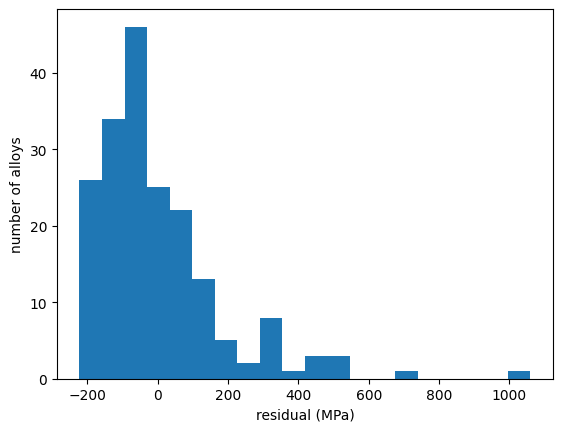

In [10]:
fig, ax = plt.subplots()
ax.hist(residuals, bins=20)
ax.set_xlabel('residual (MPa)')
ax.set_ylabel('number of alloys')

Most alloys sit within a couple of hundred MPa of the line, on both sides of zero, and a few miss it by far more.
That is the spread the sum threw away.

## MSE and RMSE

Squaring each residual before averaging is what stops the signs cancelling.
The average of the squares is the mean squared error.

In [11]:
mse = np.mean(residuals ** 2)
print(f'MSE  = {mse:.0f} MPa^2')
print(f'RMSE = {np.sqrt(mse):.1f} MPa')

MSE  = 32797 MPa^2
RMSE = 181.1 MPa


The MSE is in MPa squared, which is not a unit anyone can picture.
Taking the square root undoes that and puts the answer back in MPa: the root mean squared error, 181.1 MPa.

An individual alloy typically misses the line's prediction by about that much, in either direction, even though this is the best straight line available for this data.

## MAE

Taking the absolute value of each residual also stops the signs cancelling.
`np.abs` returns the magnitude of each residual, so negative misses no longer cancel positive ones.
The average of those is the mean absolute error, and it is in MPa already.

In [12]:
mae = np.mean(np.abs(residuals))
print(f'MAE  = {mae:.1f} MPa')

MAE  = 129.9 MPa


The MAE comes out smaller than the RMSE.
Squaring makes the few large misses count for much more than the many small ones, so the RMSE is pulled up by the tails of the histogram above.

RMSE uses squared residuals, an $L_2$ measure; MAE averages absolute residuals, an $L_1$ measure.

# $R^2$

RMSE is in MPa, tied to this one property pair.
$R^2$ reports fit quality on a scale that works for any pair, by asking what the line beats.

The thing it has to beat is the laziest model there is: ignore yield strength entirely and predict the mean tensile strength every time.
That model has residuals too, and they are just how far each alloy sits from the mean.

In [13]:
mean_residuals = y - np.mean(y)  # what the lazy model gets wrong

r_squared = 1 - np.var(residuals) / np.var(mean_residuals)
print(f'R² = {r_squared:.4f}')
print(f"fit.rvalue ** 2 = {fit.rvalue ** 2:.4f}")  # the same number, straight off the fit

R² = 0.7782
fit.rvalue ** 2 = 0.7782


0.78 either way.
Computing it from the residuals directly and reading it off `fit.rvalue` are the same calculation, arrived at two ways.

An $R^2$ of 0 would mean the line does no better than always predicting the mean, and 1 would mean it misses nothing.

> Subtracting the mean shifts a column without spreading it, so `np.var(mean_residuals)` is the same number as `np.var(y)`.
> Writing it the long way is what puts the rival model on the page instead of leaving it implied.

$R^2$ is a spectrum, not a pass/fail line.
0.78 means the fit accounts for 78% of the alloy-to-alloy variation in tensile strength in this compilation.
The other 22% is real scatter the line does not explain: composition, processing route, and microstructure absent from the two-column fit.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cd/CrystalGrain.jpg/960px-CrystalGrain.jpg" alt="Optical micrograph of a quenched titanium alloy, showing irregular crystal grains of varying size and orientation meeting at boundaries" width=520/>

Microstructure of the titanium alloy VT22 after quenching.
Photo by Edward Pleshakov, [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:CrystalGrain.jpg).

Two alloys can have the same reported yield strength and look nothing like one another under a microscope.
The fit uses only two columns of numbers, with none of that microstructural information included.

### [Check your understanding]

`Mo_equivalent` is an engineered descriptor of how strongly an alloy favors the body-centered-cubic beta phase, computed from this table's own composition columns rather than measured on a testing machine.
Put it through the same call and decide what the line is worth.

1. Build `has_mo`, the rows with both `Mo_equivalent` and `YS_MPa`, using `.dropna(subset=[...])`.
2. Fit `stats.linregress` with `Mo_equivalent` as x and `YS_MPa` as y, and print how many alloys went into it.
3. Compute that fit's residuals, and its $R^2$ from the mean baseline the way we did above.
4. Print `fit_mo.rvalue ** 2` as well and check the two agree.
5. In a comment, say how that $R^2$ compares with the 0.78 we got for tensile strength, and whether the line is beating the mean by much.

*Composition sets the phase an alloy favors, while grain size, processing route and heat treatment are nowhere in `Mo_equivalent`. What does the $R^2$ you computed support saying about predicting yield strength from beta stability alone?*

# The residual plot

$R^2$ is one number for all 190 residuals.
Plotting them against the predictor turns those 190 numbers into a picture.

`ax.axhline(0)` draws a horizontal line across the whole plot at zero, where a perfect prediction would sit.

Text(0, 0.5, 'residual (MPa)')

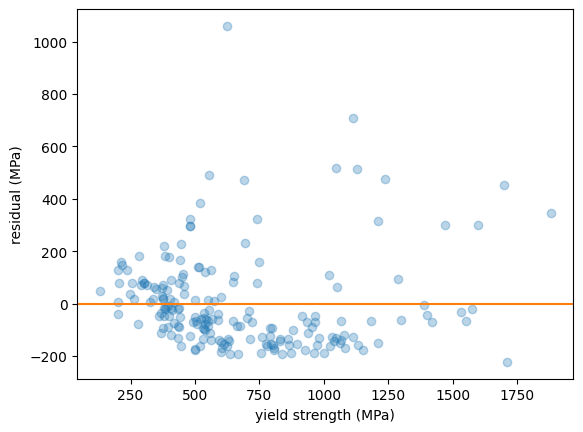

In [14]:
fig, ax = plt.subplots()
ax.scatter(x, residuals, alpha=0.3)  # alpha makes the overlapping points readable
ax.axhline(0, color='tab:orange')  # the line itself, now flat: a perfect prediction sits here
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('residual (MPa)')

A residual plot with no visible pattern, points scattered above and below zero across the whole range of yield strength, is what a good linear fit looks like.
It says the line has already captured whatever depends linearly on yield strength, and what is left over is unstructured scatter.

A residual plot with a visible curve or trend says the opposite: the line is missing something systematic, not just noise.

Ours has no curve, so a straight line is a reasonable shape for this data.
It is not the even scatter of the left sketch, though.
The large misses are almost all positive: 14 alloys sit more than 300 MPa above the line, and only one sits more than 200 MPa below it.
The misses also spread wider as yield strength rises, so the line is less reliable for the stronger alloys.

## Finding the extreme row with a mask

The largest miss is on the positive side, more than 1000 MPa above the line.
The most negative one has a stranger story: it is the point at the far right that sits below all of its neighbors.
Let's pull it out by name.

In [15]:
worst = both.loc[residuals == np.min(residuals)]  # the mask picks the single lowest point
display(worst[['eid', 'YS_MPa', 'UTS_MPa', 'YS_err', 'UTS_err']])
print(f'residual: {np.min(residuals):.0f} MPa')

,eid,YS_MPa,UTS_MPa,YS_err,UTS_err
96,TiZr-5Al,1710.0,1665.0,140.0,165.0


residual: -223 MPa


TiZr-5Al reports a UTS of 1665 MPa and a YS of 1710 MPa.
L12 defined UTS as the highest stress in the test.
For a specimen that yields, this peak follows yielding, so a reported UTS below YS calls for a closer look.
Its residual, -223 MPa, is the single most negative of all 190, which is why it sits at the bottom of the plot.

Its `YS_err` and `UTS_err` are the two largest reported for any alloy kept in this fit.

In [16]:
print(f"largest YS_err in the fit:  {np.max(both['YS_err']):.0f} MPa")
print(f"largest UTS_err in the fit: {np.max(both['UTS_err']):.0f} MPa")

largest YS_err in the fit:  140 MPa
largest UTS_err in the fit: 165 MPa


140 MPa and 165 MPa, both belonging to this same row.
Of the 190 alloys, 81 report `YS_err` and 71 report `UTS_err`.
The two maxima refer only to alloys reporting an error in the respective column.

Each reported error is larger than the 45 MPa difference between the two strengths.
This alloy is not obviously mismeasured.
Its large reported errors make the reversed order worth checking, rather than enough to declare the measurement wrong.

Catching a point like this systematically, rather than by scanning a plot, is a topic for identifying outliers, still ahead after the midterm.
For now the plot itself is the diagnostic: eyeball it, and follow up on whatever sits far from the rest.

### [Check your understanding]

Run the whole diagnosis again on a different property pair: yield strength against Young's modulus.

1. Build `has_ym`, the rows with both `YM_GPa` and `YS_MPa`, using `.dropna(subset=[...])`.
2. Fit `stats.linregress` with `YS_MPa` as x and `YM_GPa` as y, and print the $R^2$.
3. Compute the residuals of that fit.
4. Scatter those residuals against `YS_MPa`, with a horizontal line at zero.
5. In a comment, say whether the scatter looks structureless or shows a pattern.

*Optional challenge:* mark the single most negative residual on the plot with a second `ax.scatter` call in a different color.

*Is modulus a tighter or a looser fit against yield strength than tensile strength was, and is that difference consistent between the residual plot and the $R^2$?*

# Summary

* `stats.linregress` returns the fitted line as `slope`, `intercept` and `rvalue`.
* A slope has units of y per x; an intercept has the units of y and describes the model at x equal to zero.
* Interpolation predicts inside the fitted range, and extrapolation runs the same arithmetic where no data supports it.
* Vectorized prediction (`y_hat = m*x + b` over a whole array) and the residual (`y - y_hat`) turn one fitted line into 190 individual comparisons at once.
* Residuals from a least-squares fit sum to about zero on the data they were fit to, so fit quality depends on their spread, not their sum.
* RMSE and MAE express a typical miss in MPa; RMSE gives more weight to large misses because it squares the residuals.
* $R^2$, `1 - Var(residuals)/Var(mean_residuals)`, is how much of that spread the line removes compared with always predicting the mean: a spectrum from 0 to 1, not a pass/fail line.
* A residual plot turns a column of numbers into a shape. Structureless scatter about zero is a fit with nothing systematic left over; visible structure, or one extreme point, says otherwise.

Across these 190 titanium alloys the line accounts for 78% of the variation in tensile strength, which is a good fit, and an individual alloy still typically sits about 181 MPa off it in either direction.
TiZr-5Al has the most negative residual: at its 1710 MPa yield strength the line predicts 1888 MPa and the measurement reports 1665.

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [SciPy documentation: `scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)